
# CNN from Scratch (TensorFlow Equivalent)

In [2]:
! pip install tensorflow

  Using cached markdown_it_py-4.0.0-py3-none-any.whl.metadata (7.3 kB)
  Using cached mdurl-0.1.2-py3-none-any.whl.metadata (1.6 kB)
   ---------------------------------------- 0.0/350.6 MB ? eta -:--:--
   ---------------------------------------- 1.0/350.6 MB 7.2 MB/s eta 0:00:49
   ---------------------------------------- 2.9/350.6 MB 8.0 MB/s eta 0:00:44
    --------------------------------------- 4.7/350.6 MB 8.1 MB/s eta 0:00:43
    --------------------------------------- 6.3/350.6 MB 8.2 MB/s eta 0:00:42
    --------------------------------------- 8.1/350.6 MB 8.3 MB/s eta 0:00:42
   - -------------------------------------- 9.7/350.6 MB 8.3 MB/s eta 0:00:42
   - -------------------------------------- 11.5/350.6 MB 8.3 MB/s eta 0:00:41
   - -------------------------------------- 13.1/350.6 MB 8.3 MB/s eta 0:00:41
   - -------------------------------------- 14.9/350.6 MB 8.3 MB/s eta 0:00:41
   - -------------------------------------- 16.3/350.6 MB 8.3 MB/s eta 0:00:41
   - -------


[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [3]:

import tensorflow as tf
from tensorflow.keras import layers, models
import numpy as np
import matplotlib.pyplot as plt
import os
import cv2

# Ensure reproducibility
tf.random.set_seed(42)
np.random.seed(42)



## 1. Data Loading (Subset CIFAR-10)
Load the subset of CIFAR-10 containing images of birds, cats, and dogs, maintaining the standard `(H, W, C)` dimensions that TensorFlow natively expects.


In [7]:

def load_cifar_subset(base_dir):
    categories = ['bird', 'cat', 'dog']
    X, y = [], []
    for label, category in enumerate(categories):
        folder = os.path.join(base_dir, category)
        if not os.path.exists(folder):
            continue
        for file in os.listdir(folder):
            filepath = os.path.join(folder, file)
            img = cv2.imread(filepath)
            if img is not None:
                img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
                img = cv2.resize(img, (32, 32))
                img = img.astype(np.float32) / 255.0
                # Tensorflow natively supports (32, 32, 3) 
                X.append(img)
                y.append(label)
    return np.array(X), np.array(y)

print("Loading training data...")
X_train, y_train = load_cifar_subset('cifar10/train')
print("Loading testing data...")
X_test, y_test = load_cifar_subset('cifar10/test')

Y_train_enc = tf.keras.utils.to_categorical(y_train, 3)
Y_test_enc = tf.keras.utils.to_categorical(y_test, 3)

print(f"X_train shape: {X_train.shape} | Y_train_enc shape: {Y_train_enc.shape}")
print(f"X_test shape:  {X_test.shape}  | Y_test_enc shape:  {Y_test_enc.shape}")


Loading training data...
Loading testing data...
X_train shape: (3000, 32, 32, 3) | Y_train_enc shape: (3000, 3)
X_test shape:  (600, 32, 32, 3)  | Y_test_enc shape:  (600, 3)


## 2. CNN Architecture
We define exactly the same network layout:
- **Block 1**: Conv2D (8 filters, 3x3, padding='same') -> MaxPool2D (2x2)
- **Block 2**: Conv2D (16 filters, 3x3, padding='same') -> MaxPool2D (2x2)
- **Classifier**: Flatten -> Dense (32) -> Dense (3)


In [ ]:

model = models.Sequential([
    # Block 1
    layers.Conv2D(8, (3, 3), strides=(1, 1), padding='same', activation='relu', input_shape=(32, 32, 3), name='conv2d_1'),
    layers.MaxPooling2D((2, 2), strides=(2, 2), name='max_pooling2d_1'),
    
    # Block 2
    layers.Conv2D(16, (3, 3), strides=(1, 1), padding='same', activation='relu', name='conv2d_2'),
    layers.MaxPooling2D((2, 2), strides=(2, 2), name='max_pooling2d_2'),
    
    # Classifier
    layers.Flatten(name='flatten'),
    layers.Dense(32, activation='relu', name='dense_1'),
    layers.Dense(3, activation='softmax', name='dense_2')
])

model.summary()

# Let's extract weights and biases manually to match the exact output table of our Custom NumPy CNN
print("\n--- Manual Parameter Breakdown ---")
total_tf_weights = 0
total_tf_biases = 0
print(f"{'Layer':<15} | {'Weights Shape':<15} | {'Biases Shape':<15} | {'Parameters':<10}")
print("-" * 65)

for layer in model.layers:
    weights = layer.get_weights()
    if len(weights) > 0:
        w_shape = weights[0].shape
        b_shape = weights[1].shape
        w_params = np.prod(w_shape)
        b_params = np.prod(b_shape)
        params = w_params + b_params
        total_tf_weights += w_params
        total_tf_biases += b_params
        print(f"{layer.name:<15} | {str(w_shape):<15} | {str(b_shape):<15} | {params:<10}")
    else:
        print(f"{layer.name:<15} | {'-':<15} | {'-':<15} | {'0':<10}")
print("-" * 65)
print(f"Total Weights: {total_tf_weights}")
print(f"Total Biases:  {total_tf_biases}")
print(f"Total Parameters: {total_tf_weights + total_tf_biases}")


TensorFlow automatically counts the parameters for us via model.summary():


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_1 (Conv2D)               │ (None, 32, 32, 8)      │           224 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 16, 16, 8)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 16, 16, 16)     │         1,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 8, 8, 16)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 1024)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 32)             │        32,800 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 3)              │            99 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 34,291 (133.95 KB)

 Trainable params: 34,291 (133.95 KB)

 Non-trainable params: 0 (0.00 B)


--- Manual Parameter Breakdown ---
Layer           | Weights Shape   | Biases Shape    | Parameters
-----------------------------------------------------------------
conv2d_1        | (3, 3, 3, 8)    | (8,)            | 224       
max_pooling2d_1 | -               | -               | 0         
conv2d_2        | (3, 3, 8, 16)   | (16,)           | 1168      
max_pooling2d_2 | -               | -               | 0         
flatten         | -               | -               | 0         
dense_1         | (1024, 32)      | (32,)           | 32800     
dense_2         | (32, 3)         | (3,)            | 99        
-----------------------------------------------------------------
Total Weights: 34232
Total Biases:  59
Total Parameters: 34291



## 3. Training & Evaluation
We compile the model with Stochastic Gradient Descent to exactly mirror our Native NumPy implementation, then train it for 20 epochs!


Initiating TensorFlow Training Process...
Epoch 1/20
47/47 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - accuracy: 0.4053 - loss: 1.0816 - val_accuracy: 0.3950 - val_loss: 1.1050
Epoch 2/20
47/47 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.4300 - loss: 1.0603 - val_accuracy: 0.4333 - val_loss: 1.0888
Epoch 3/20
47/47 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.4470 - loss: 1.0474 - val_accuracy: 0.4550 - val_loss: 1.0727
Epoch 4/20
47/47 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.4640 - loss: 1.0330 - val_accuracy: 0.4683 - val_loss: 1.0547
Epoch 5/20
47/47 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.4763 - loss: 1.0194 - val_accuracy: 0.4933 - val_loss: 1.0416
Epoch 6/20
47/47 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - accuracy: 0.4917 - loss: 1.0071 - val_accuracy: 0.5050 - val_loss: 1.0289
Epoch 7/20
47/47 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - accuracy: 0.4967 - loss: 0.9941 - val_accuracy: 0.5083 - val_loss: 1.0170
Epoch 8/20
47/47 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.5097

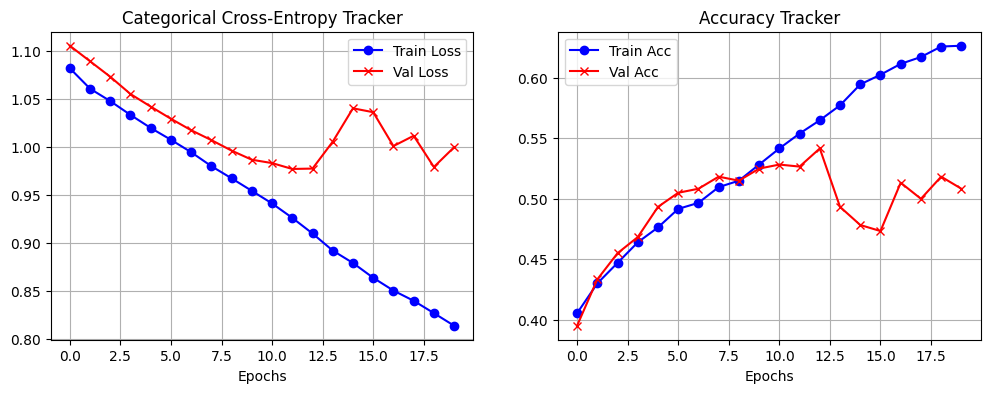

In [ ]:

model.compile(optimizer=tf.keras.optimizers.SGD(learning_rate=0.05),
              loss='categorical_crossentropy',
              metrics=['accuracy'])

print("Initiating TensorFlow Training Process...")
history = model.fit(X_train, Y_train_enc, epochs=20, batch_size=64, validation_data=(X_test, Y_test_enc))

# Plotting
plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.plot(history.history['loss'], label='Train Loss', color='blue', marker='o')
plt.plot(history.history['val_loss'], label='Val Loss', color='red', marker='x')
plt.title('Categorical Cross-Entropy Tracker')
plt.xlabel('Epochs')
plt.legend()
plt.grid(True)

plt.subplot(1, 2, 2)
plt.plot(history.history['accuracy'], label='Train Acc', color='blue', marker='o')
plt.plot(history.history['val_accuracy'], label='Val Acc', color='red', marker='x')
plt.title('Accuracy Tracker')
plt.xlabel('Epochs')
plt.legend()
plt.grid(True)
plt.show()